#Image Processing with OpenCV

## Task 1: Color Space Conversion

Using your low-light photo, convert it to Grayscale, HSV, and RGB (remember OpenCV loads as BGR by default). Display all versions side by side.

Then, looking specifically at your own photo, note which HSV channel best preserves detail in the darkest part of the frame, and why you think that's the case for this particular shot.

In [1]:
#import the required libraries

import cv2
import matplotlib.pyplot as plt
import numpy as np

In [2]:
#reading the image in a variable
low_light_img = cv2.imread("/content/Manishraj_lowlight.png")

In [3]:
if low_light_img is None:
    print("Image not found!")
else:
    print("Image loaded successfully.")

Image loaded successfully.


In [4]:
#The image if stroed in BGR formated by default. We can convert them to different versions here

gray_image = cv2.cvtColor(low_light_img,cv2.COLOR_BGR2GRAY)
rgb_image = cv2.cvtColor(low_light_img,cv2.COLOR_BGR2RGB)
hsv_image = cv2.cvtColor(low_light_img,cv2.COLOR_BGR2HSV)

In [5]:
#split the hsv chanbels
h_channel , s_channel , v_channel = cv2.split(hsv_image)

In [6]:
#defining a generic func to display images
def disp_img(images,titles,figsize=(18,5),cmap=None):
  plt.figure(figsize=figsize)
  for i in range(len(images)):
    plt.subplot(1,len(images),i+1)
    if cmap is not None:
      plt.imshow(images[i],cmap=cmap)
    else:
      plt.imshow(images[i])
    plt.title(titles[i])
  plt.show()

In [7]:
#hsv image cannot be directly diaplyed using matplot so we convert it to RGB first

hsv_display = cv2.cvtColor(hsv_image,cv2.COLOR_HSV2RGB)

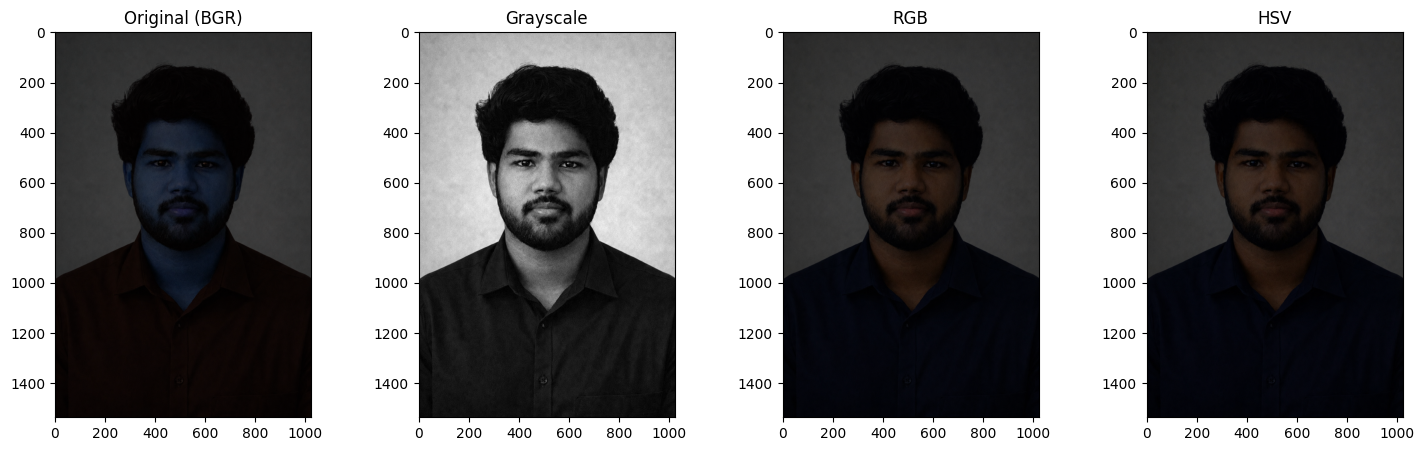

In [8]:
disp_img(
    images=[
        low_light_img,
        gray_image,
        rgb_image,
        hsv_display
    ],
    titles=[
        "Original (BGR)",
        "Grayscale",
        "RGB",
        "HSV"
    ],
    cmap="gray"
)


The low-light image was successfully converted into Grayscale, RGB, and HSV color spaces.

- The Grayscale image removes all color information and represents the image using only intensity values, making facial features and edges easier to observe.

- The RGB image displays the original colors correctly because OpenCV images were converted from the default BGR format to RGB before displaying with Matplotlib.

- The HSV image separates color information (Hue and Saturation) from brightness (Value), making it useful for analyzing illumination changes and image processing tasks.

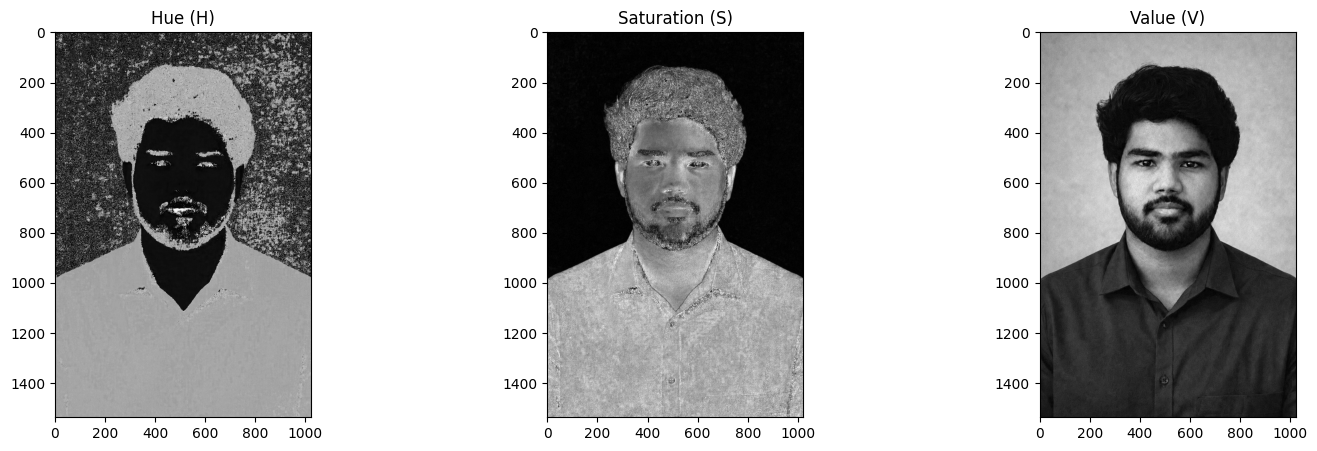

In [9]:
#Displaing each HSV channel as separate image to infer which channel has higher impact in retaing the info

disp_img(
    images=[
        h_channel,
        s_channel,
        v_channel
    ],
    titles=[
        "Hue (H)",
        "Saturation (S)",
        "Value (V)"
    ],
    cmap="gray"
)

- Value (V) channel preserves the most detail in dark areas.

- It represents the brightness (intensity) of the image.
Facial features are more visible in the V channel.

- Hue (H) channel mainly shows color information and becomes noisy in low-light conditions.

- Saturation (S) channel shows color intensity but loses details because the image has very little color in low light.


## Task 2. Image Blending via Feature Matching



Using your normal-light and low-light photos of the same scene, detect keypoints and descriptors in both with ORB, then match them with a brute-force (or FLANN) matcher. Use the good matches to estimate a homography with cv2.findHomography() (RANSAC), and warp the low-light photo onto the normal-light photo's plane with cv2.warpPerspective().

Once aligned, blend the two images with cv2.addWeighted() using at least two different weight combinations. Report how many good matches you found and comment on how well the homography aligned the two shots.

In [10]:
#reading the image in a variable
normal_img = cv2.imread("/content/Manishraj.png")
low_light_img = cv2.imread("/content/Manishraj_lowlight.png")

In [11]:
if normal_img is None or low_light_img is None:
    print("Error loading images.")
else:
    print("Both images loaded successfully.")

Both images loaded successfully.


In [12]:
#converting both imags to grayscale

gray_normal = cv2.cvtColor(normal_img, cv2.COLOR_BGR2GRAY)
gray_low = cv2.cvtColor(low_light_img, cv2.COLOR_BGR2GRAY)

In [13]:
#ORB is used to detect keypoints and compute descriptors from both images

orb = cv2.ORB_create() # this creates an ORB obj with default settings

In [14]:
def detect_orb_features(img):

  kps, desc = orb.detectAndCompute(img,None)
  return kps,desc

In [15]:
kp_normal, desc_normal = detect_orb_features(gray_normal)
kp_low, desc_low = detect_orb_features(gray_low)

In [16]:
print("Normal Image Keypoints :", len(kp_normal))
print("Low-Light Image Keypoints :", len(kp_low))

Normal Image Keypoints : 500
Low-Light Image Keypoints : 147


By creating default object for ORB, the limit is set to upto 500 keypoints which is acheived in normal image. But since the low light image is a bit dark, the KPs maybe less certain leading to a lesser number of KPs


In [17]:
#Draw both the keypoints over the images

normal_kp_img = cv2.drawKeypoints(
    normal_img,
    kp_normal,
    None,
    color=(0,0,255),
    flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS
)

low_kp_img = cv2.drawKeypoints(
    low_light_img,
    kp_low,
    None,
    color=(255,0,0),
    flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS
)

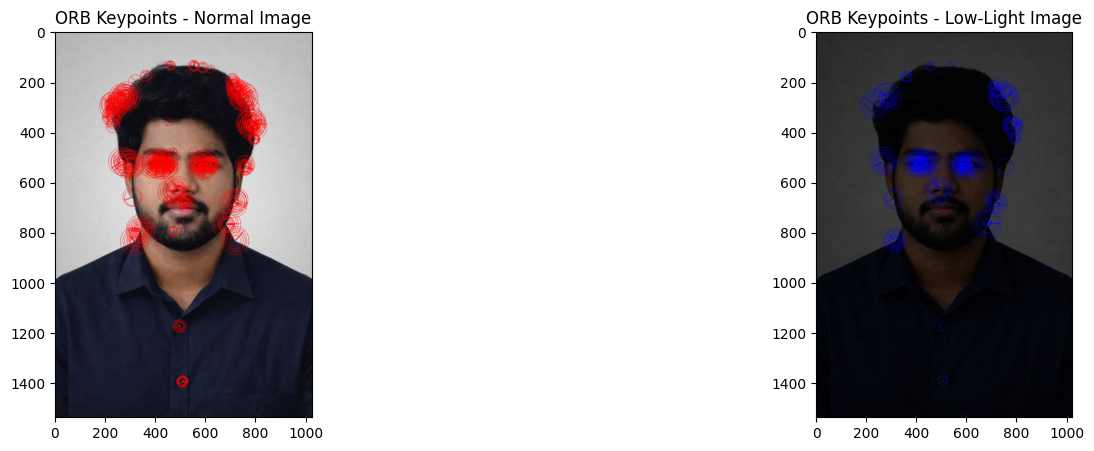

In [18]:
disp_img(
    images=[
        cv2.cvtColor(normal_kp_img, cv2.COLOR_BGR2RGB),
        cv2.cvtColor(low_kp_img, cv2.COLOR_BGR2RGB)
    ],
    titles=[
        "ORB Keypoints - Normal Image",
        "ORB Keypoints - Low-Light Image"
    ]
)

ORB successfully detected distinctive keypoints in both the normal-light and low-light images.

Most keypoints were concentrated around high-texture and high-contrast regions such as the eyes, hair, nose, beard, and shirt collar. These regions are easier for ORB to identify because they contain strong intensity variations.

The normal-light image produced more detectable keypoints than the low-light image since better illumination preserves more image details. Although the low-light image contains fewer keypoints, the important facial features are still detected, making the images suitable for feature matching in the next step.

In [19]:
#now we can find the best match between the images using the Brute force matcher whcih owrks by comparing the descpritor of both images

bf = cv2.BFMatcher(cv2.NORM_HAMMING,crossCheck=True)

In [20]:
matches = bf.match(desc_normal,desc_low)

In [21]:
#sort the matches

matches = sorted(matches,key=lambda x:x.distance)

In [22]:
print(f"Total Matches Found: {len(matches)}")

Total Matches Found: 107


In [23]:
#we can assume and select the top 50 matches to be good matches

good_matches = matches[:50]

In [24]:
matched_image = cv2.drawMatches(
    normal_img,
    kp_normal,
    low_light_img,
    kp_low,
    good_matches,
    None,
    flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS
)

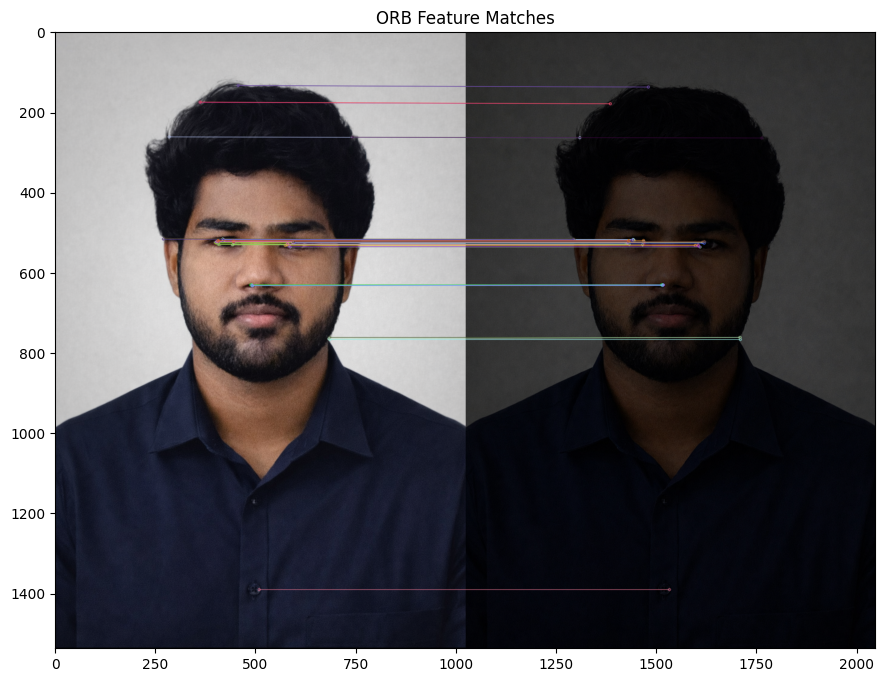

In [25]:
plt.figure(figsize=(18,8))
plt.imshow(cv2.cvtColor(matched_image, cv2.COLOR_BGR2RGB))
plt.title("ORB Feature Matches")
plt.show()


ORB found a total of **107 feature matches** between the normal-light and low-light images. The best **50 matches** were selected for further processing.

Most of the matched keypoints correspond to the same facial features, including the eyes, hair, nose, beard, and shirt collar. Since both images represent the same scene with only a change in lighting, the matches are accurate and well distributed.

These reliable feature matches provide a strong basis for estimating the homography and aligning the two images.

In [26]:
#exact the cordinates of the matching points
src_points = np.float32(
    [kp_normal[m.queryIdx].pt for m in good_matches]
).reshape(-1, 1, 2)

dst_points = np.float32(
    [kp_low[m.trainIdx].pt for m in good_matches]
).reshape(-1, 1, 2)

In [27]:
H, mask = cv2.findHomography(
    dst_points,
    src_points,
    cv2.RANSAC,
    5.0
)

In [28]:
print("Homography Matrix:\n")
print(H)

Homography Matrix:

[[ 1.00478225e+00  2.80009020e-03 -3.87160232e-01]
 [ 1.92901979e-03  1.01540126e+00 -6.96434301e+00]
 [ 8.51529871e-07  7.63109830e-06  1.00000000e+00]]


In [29]:
height, width = normal_img.shape[:2]

aligned_low_light = cv2.warpPerspective(
    low_light_img,
    H,
    (width, height)
)

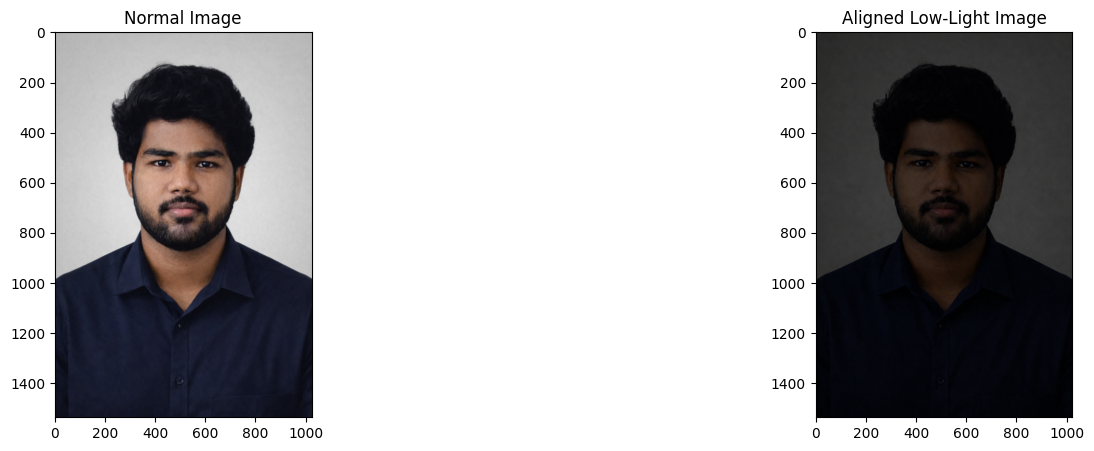

In [30]:
disp_img(
    images=[
        cv2.cvtColor(normal_img, cv2.COLOR_BGR2RGB),
        cv2.cvtColor(aligned_low_light, cv2.COLOR_BGR2RGB)
    ],
    titles=[
        "Normal Image",
        "Aligned Low-Light Image"
    ]
)

The homography matrix was successfully estimated using the matched keypoints and the RANSAC algorithm.

After applying the perspective transformation, the low-light image aligned well with the normal-light image. Since both photographs were captured from nearly the same viewpoint, only a small geometric transformation was required.

The aligned image is suitable for image blending without noticeable misalignment.

In [31]:
blend_50 = cv2.addWeighted(
    normal_img,
    0.5,
    aligned_low_light,
    0.5,
    0
)

blend_70 = cv2.addWeighted(
    normal_img,
    0.7,
    aligned_low_light,
    0.3,
    0
)

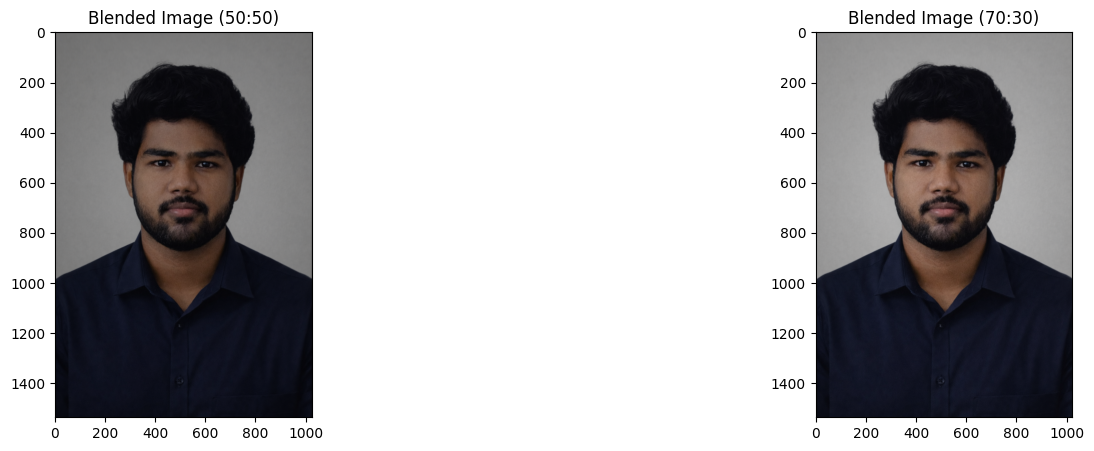

In [32]:
disp_img(
    images=[
        cv2.cvtColor(blend_50, cv2.COLOR_BGR2RGB),
        cv2.cvtColor(blend_70, cv2.COLOR_BGR2RGB)
    ],
    titles=[
        "Blended Image (50:50)",
        "Blended Image (70:30)"
    ]
)


Two blended images were generated using different weight combinations.

The **50:50 blend** combines equal contributions from both images, producing a balanced result that retains information from the normal-light and low-light photographs.

The **70:30 blend** gives greater importance to the normal-light image, resulting in a brighter and clearer output while still preserving some characteristics of the low-light image.

Both blending techniques successfully combine information from the two aligned images without introducing visible artifacts.

## Task 3. Geometric Transformations   

Pick a personal reference number: the last 2 digits of your employee ID (or, if you don't have one yet, the last 2 digits of your phone number). Compute angle = (your number) x 3 degrees and scale = 1 + (last digit of your number / 10).

Apply translation, this rotation, this scale factor, and one affine transform to your objects photo. State the reference number and computed values explicitly in your notebook so your mentor can double check them.

### Last two digits of number : **16**

Computed Values:

- Rotation Angle = 16 * 3 = **48**
- Scale Factor = 1 + (6 / 10) = **1.6**


In [33]:
#reading the image in a variable
object_image = cv2.imread("/content/obj1.jpeg")

In [34]:
if object_image is None:
    print("Image not found!")
else:
    print("Image loaded successfully.")

Image loaded successfully.


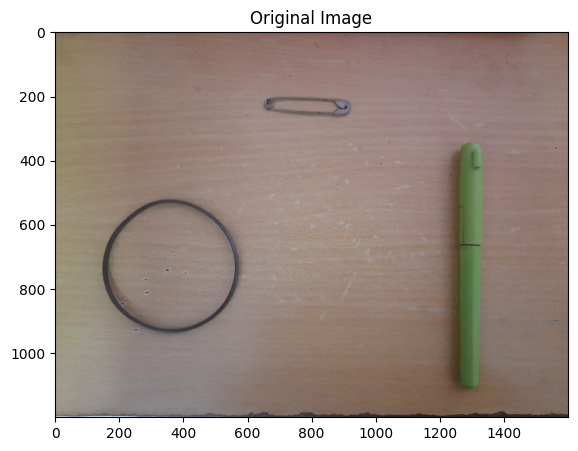

In [35]:
disp_img(
    images=[cv2.cvtColor(object_image, cv2.COLOR_BGR2RGB)],
    titles=["Original Image"]
)

In [36]:
#1-translation
'''
Translation shifts every pixel in the image by a fixed distance in the horizontal and vertical directions. It changes only the position of the objects without affecting their size, shape, or orientation.
#first for translation the matrix looks liek this

              |1  0  tx|
              |0  1  ty|

where
tx = horizontal movement
ty = vertical movement
'''

height,width = object_image.shape[:2]

In [37]:
object_image.shape

(1200, 1600, 3)

In [38]:
#assuming we want to move the image 120 pix right and 80 pix down

translation_matrix = np.float32([
    [1, 0, 120],
    [0, 1, 80]
])

In [39]:
#this fuction is used to do anykind of affine trnasfomration
translated_image = cv2.warpAffine(
    object_image,
    translation_matrix,
    (width,height)
)

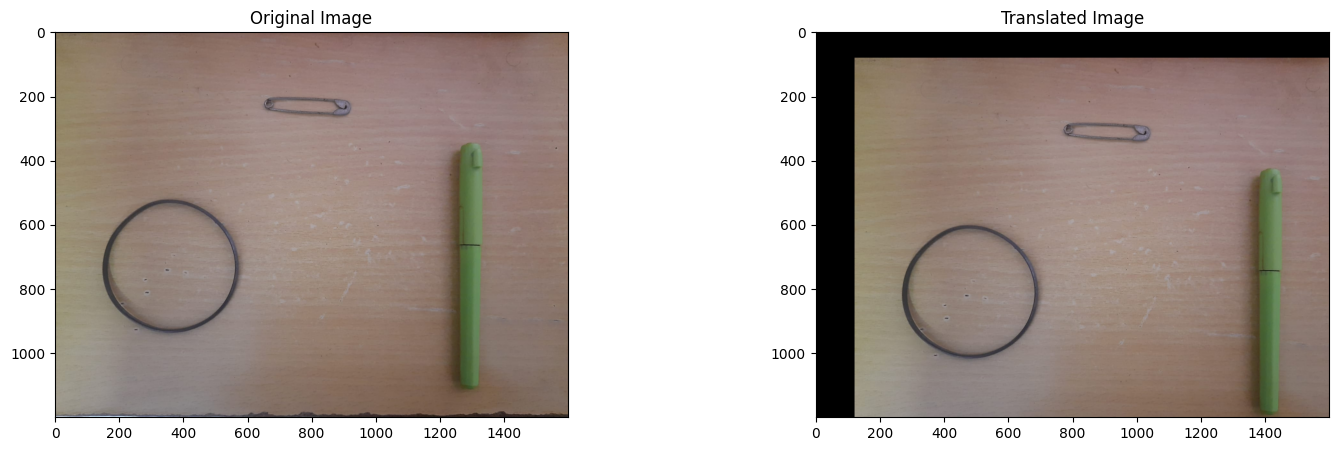

In [40]:
disp_img(
    images=[
        cv2.cvtColor(object_image, cv2.COLOR_BGR2RGB),
        cv2.cvtColor(translated_image, cv2.COLOR_BGR2RGB)
    ],
    titles=[
        "Original Image",
        "Translated Image"
    ]
)

The translation transformation successfully shifted all the objects toward the right and downward.

The relative positions, sizes, and orientations of the bracelet, safety pin, and pen remained unchanged. Only their locations within the image changed, demonstrating that translation moves an image without altering its geometric properties.

In [41]:
#2-rotation

#Rotation means turning the image around a fixed point

#finding the center
center = (width // 2, height // 2)

In [42]:
#creating a rotation matrix
rotation_matrix = cv2.getRotationMatrix2D(
    center,
    48,
    1.0
)

In [43]:
rotated_image = cv2.warpAffine(
    object_image,
    rotation_matrix,
    (width, height)
)

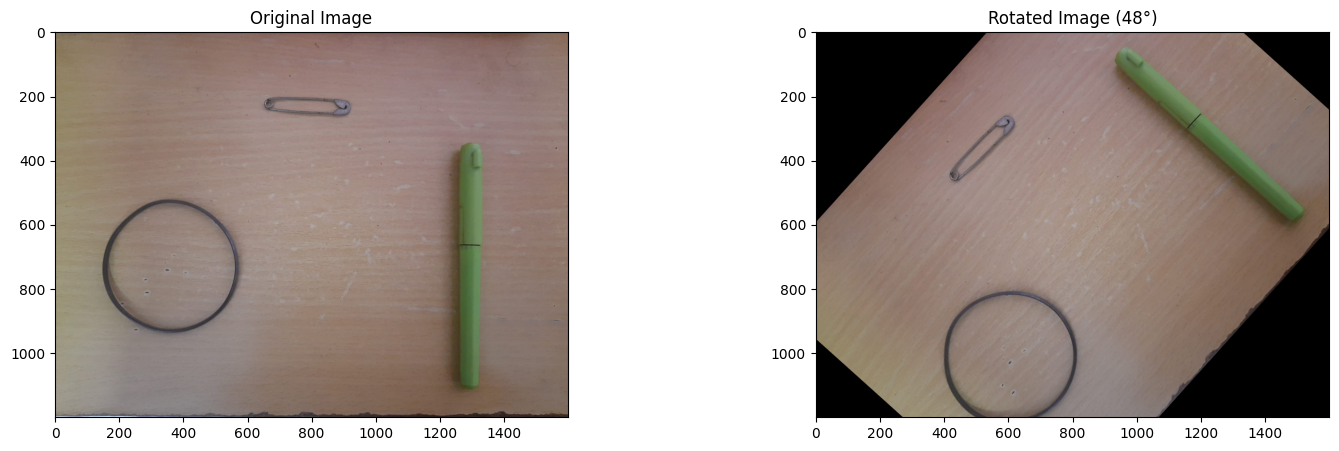

In [44]:
disp_img(
    images=[
        cv2.cvtColor(object_image, cv2.COLOR_BGR2RGB),
        cv2.cvtColor(rotated_image, cv2.COLOR_BGR2RGB)
    ],
    titles=[
        "Original Image",
        "Rotated Image (48°)"
    ]
)

The image was successfully rotated by **48°** about its center. The objects maintained their original shape and size, but their orientation changed according to the specified angle.

When given a positive angle it rotates counter-clock wise and clock wise for negative angle

In [45]:
#3-scaling by facotr of 1.6
#Scaling changes the size of an image while preserving its shape and proportions
# we can use the same roationmatrix by setting scale to 1.6
scale_factor = 1.6

scaled_matrix = cv2.getRotationMatrix2D(
    center,
    0,
    1.6
)

scaled_image = cv2.warpAffine(
    object_image,
    scaled_matrix,
    (width, height)
)


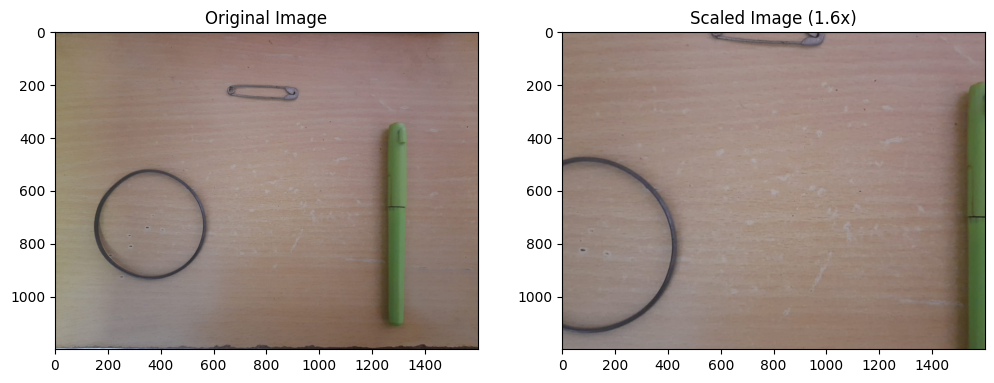

In [46]:
disp_img(
    images=[
        cv2.cvtColor(object_image, cv2.COLOR_BGR2RGB),
        cv2.cvtColor(scaled_image, cv2.COLOR_BGR2RGB)
    ],
    titles=[
        "Original Image",
        "Scaled Image (1.6x)"
    ],
    figsize=(12,6)
)

In [47]:
#4-Affine transformation
#it combines the above operations together rather than as individaul

rows, cols = object_image.shape[:2]

source_points = np.float32([
    [50, 50],
    [cols - 50, 50],
    [50, rows - 50]
])

destination_points = np.float32([
    [80, 30],
    [cols - 80, 80],
    [100, rows - 80]
])

In [48]:
affine_matrix = cv2.getAffineTransform(
    source_points,
    destination_points
)

In [49]:
affine_image = cv2.warpAffine(
    object_image,
    affine_matrix,
    (cols, rows)
)

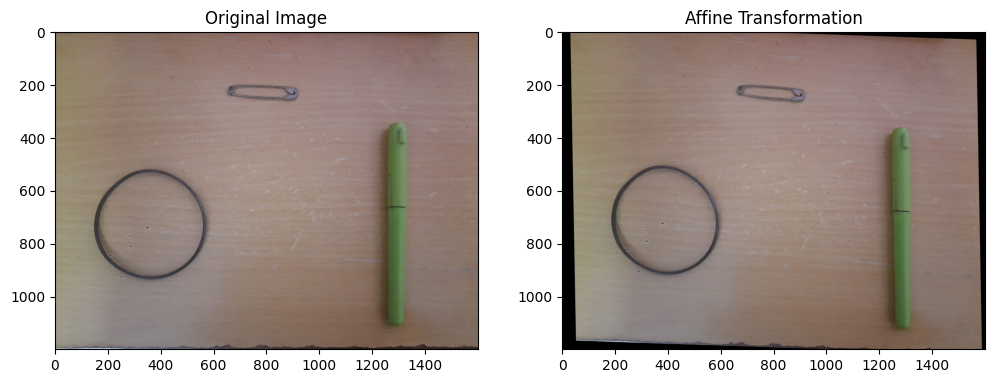

In [50]:
disp_img(
    images=[
        cv2.cvtColor(object_image, cv2.COLOR_BGR2RGB),
        cv2.cvtColor(affine_image, cv2.COLOR_BGR2RGB)
    ],
    titles=[
        "Original Image",
        "Affine Transformation"
    ],
    figsize=(12,6)
)

- **Translation** shifted the image without changing the size or orientation of the objects.
- **Rotation** rotated the image by **48°** around its center.
- **Scaling** enlarged the image using the computed scale factor of **1.6**.
- **Affine Transformation** modified the image geometry by mapping three reference points to new positions.

